## Тема 2. Основні структури  даних

## Завдання 1: Імітація роботи сервісного центру.

### Problem
Правильне застосування структур даних для конкретних завдань

### Approach
Queueing Theory, або Теорія масового обслуговування (ТМО): вартість використання черги Queue зі стандартного модулю queue Python порівняно з
- двосторонньою чергою deque з модуля collections,
- звичайним списком
Для коректності порівняння структури даних поміщено в однакове стохастичне середовище M/M/1, яке відповідає вимозі завдання "постійний потік заявок та їх обробка" - в даному випадку на кожному кроці:
- генерація: Narrivals∼Pois(λ) 
- обслуговування: Nservice∼Pois(μ)

### Implementation
2 основні функції: 
- generate_request(): генерує нові заявки та додає їх до черги 
- process_request(): обробляє заявки, видаляючи їх із черги. 
Головний цикл програми виконує ці функції, імітуючи постійний потік нових заявок та їх обробку.

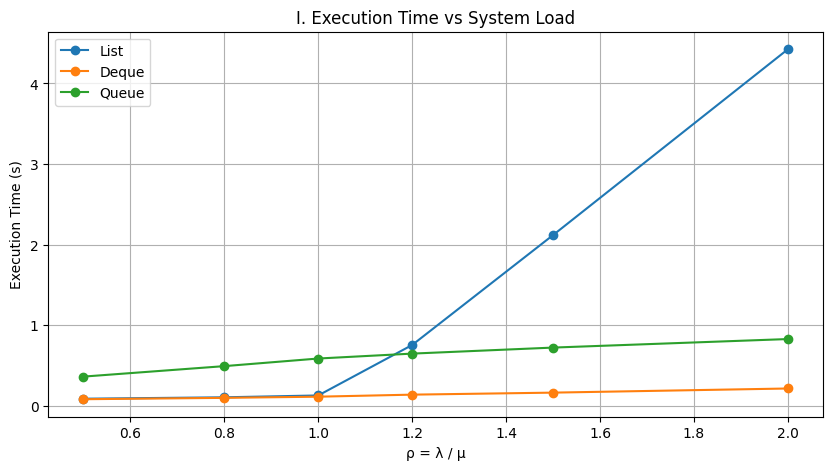

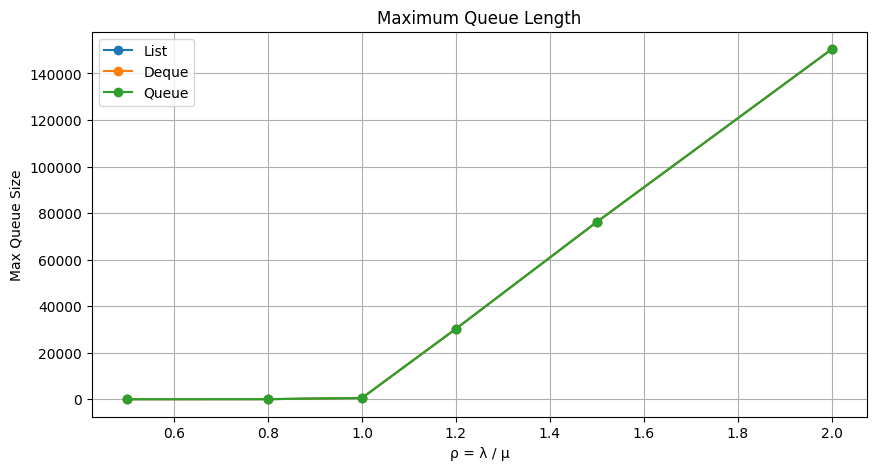

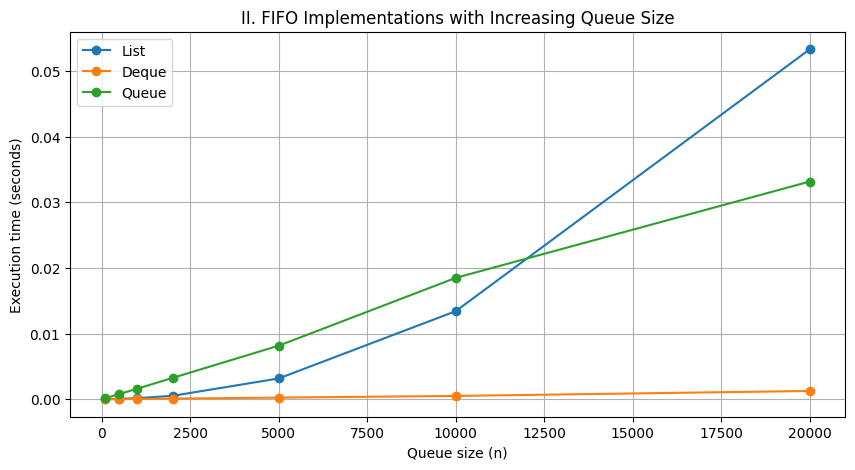

In [18]:
import time
import numpy as np
import matplotlib.pyplot as plt

from collections import deque
from queue import Queue

#Опис структур даних:
structures = {

    "List": {
        "create": lambda: [],
        "add": lambda q, x: q.append(x),
        "remove": lambda q: q.pop(0),
        "empty": lambda q: len(q) == 0,
        "size": lambda q: len(q)
    },

    "Deque": {
        "create": lambda: deque(),
        "add": lambda q, x: q.append(x),
        "remove": lambda q: q.popleft(),
        "empty": lambda q: len(q) == 0,
        "size": lambda q: len(q)
    },

    "Queue": {
        "create": lambda: Queue(),
        "add": lambda q, x: q.put(x),
        "remove": lambda q: q.get(),
        "empty": lambda q: q.empty(),
        "size": lambda q: q.qsize()
    }
}

# Створення заявки:
def generate_request(queue_obj, ops, request_id):

    request = {
        "id": request_id
    }

    ops["add"](queue_obj, request)

    return request_id + 1

# Обробка заявки:
def process_request(queue_obj, ops):

    if not ops["empty"](queue_obj):

        ops["remove"](queue_obj)

        return True

    return False

# Моделювання M/M/1:
def simulate(structure_name,
             arrival_stream,
             service_stream):

    ops = structures[structure_name]

    q = ops["create"]()

    request_id = 0
    max_queue = 0

    start = time.perf_counter()

    for i in range(len(arrival_stream)):

        for _ in range(arrival_stream[i]):
            request_id = generate_request(
                q,
                ops,
                request_id
            )

        for _ in range(service_stream[i]):
            process_request(
                q,
                ops
            )

        current_size = ops["size"](q)

        if current_size > max_queue:
            max_queue = current_size

    elapsed = time.perf_counter() - start

    return elapsed, max_queue

# Параметри експерименту:
steps = 30000

mu = 5

rho_values = [
    0.5,
    0.8,
    1.0,
    1.2,
    1.5,
    2.0
]

# Збереження результатів: 
times = {
    name: []
    for name in structures
}

max_queues = {
    name: []
    for name in structures
}

# Проведення експерименту:
for rho in rho_values:

    lam = rho * mu

    arrival_stream = np.random.poisson(
        lam,
        size=steps
    )

    service_stream = np.random.poisson(
        mu,
        size=steps
    )

    for structure_name in structures:

        elapsed, max_queue = simulate(
            structure_name,
            arrival_stream,
            service_stream
        )

        times[structure_name].append(elapsed)

        max_queues[structure_name].append(max_queue)

# Графік часу виконання:
plt.figure(figsize=(10, 5))

for structure_name in structures:

    plt.plot(
        rho_values,
        times[structure_name],
        marker="o",
        label=structure_name
    )

plt.title("I. Execution Time vs System Load")
plt.xlabel("ρ = λ / μ")
plt.ylabel("Execution Time (s)")

plt.grid(True)
plt.legend()
plt.show()

# Графік максимальної довжини черги:
plt.figure(figsize=(10, 5))

for structure_name in structures:

    plt.plot(
        rho_values,
        max_queues[structure_name],
        marker="o",
        label=structure_name
    )

plt.title("Maximum Queue Length")
plt.xlabel("ρ = λ / μ")
plt.ylabel("Max Queue Size")

plt.grid(True)
plt.legend()
plt.show()

# Чиста вартість операцій FIFO для структур даних:
def fifo_list(n):

    q = list(range(n))

    start = time.perf_counter()

    while q:
        q.pop(0)

    return time.perf_counter() - start


def fifo_deque(n):

    q = deque(range(n))

    start = time.perf_counter()

    while q:
        q.popleft()

    return time.perf_counter() - start


def fifo_queue(n):

    q = Queue()

    for i in range(n):
        q.put(i)

    start = time.perf_counter()

    while not q.empty():
        q.get()

    return time.perf_counter() - start

sizes = [
    100,
    500,
    1000,
    2000,
    5000,
    10000,
    20000
]

# Збір результатів:
list_times = []
deque_times = []
queue_times = []

for n in sizes:

    list_times.append(
        fifo_list(n)
    )

    deque_times.append(
        fifo_deque(n)
    )

    queue_times.append(
        fifo_queue(n)
    )

# Графік Вартість FIFO-операцій:
plt.figure(figsize=(10, 5))

plt.plot(
    sizes,
    list_times,
    marker="o",
    label="List"
)

plt.plot(
    sizes,
    deque_times,
    marker="o",
    label="Deque"
)

plt.plot(
    sizes,
    queue_times,
    marker="o",
    label="Queue"
)

plt.title("II. FIFO Implementations with Increasing Queue Size")
plt.xlabel("Queue size (n)")
plt.ylabel("Execution time (seconds)")

plt.grid(True)

plt.legend()

plt.show()

### Output / Interpretation

Порівняння структур даних `list`, `deque` та `queue.Queue` в умовах моделі M/M/1 показало:

- найкращі результати демонструє `deque` - час виконання для цієї структури залишається практично сталим за різних значень коефіцієнта завантаження (\rho), що підтверджує теоретичну складність операцій (O(1)) (графіки I–II).
- зЗвичайний список за стабільного навантаження ((\rho < 1)) працює майже так само ефективно, як `deque`, однак після переходу межі стійкості системи ((\rho > 1)) його продуктивність різко погіршується через лінійну складність операції `pop(0)` — (O(n)). Зростання часу виконання корелює зі збільшенням максимальної довжини черги. Тому за стабільного навантаження має сенс використовувати звичайний список, бо з точки зору пам’яті він є компактнішим, оскільки реалізований як динамічний масив, але хоч `Deque` потребує дещо більше пам’яті, вона забезпечує значно кращу масштабованість при зростанні черги.
- структура `queue.Queue` також має теоретичну складність (O(1)), проте в експериментах поступалася `deque` за швидкодією. Додатковий FIFO-бенчмарк (графік II) підтвердив цей результат. Ймовірною причиною є накладні витрати механізмів синхронізації. 

## Загалиний висновок
Для симуляції роботи сервісного центру в умовах однопотокової системи типу M/M/1 найбільш доцільною структурою даних є `deque`. 

## Рекомендація
Для підтверждення ефективності `queue.Queue` порівняно з  `deque` необхідні додаткові дослідження в багатоканальних моделях M/M/c.


## Task 2: Перевірка на паліндромність.

### Problem
чи є рядок паліндромом

### Approach
Алгоритми та стркутри даних: deque з модуля collections у Python. Для перевірки: група симетрій C2 як інваріант


### Implementation
1. Реалізувати функцію, яка приймає рядок як вхідний параметр, додає всі його символи до двосторонньої черги deque з модуля collections в Python, а потім порівнює символи з обох кінців черги, щоб визначити, чи є рядок паліндромом. 
2. Програма повинна враховувати як рядки з парною, так і з непарною кількістю символів, а також бути нечутливою до регістру та пробілів.


### Опціонально:

**перевірка: чи є рядок паліндроном перевіряється за допомогою індексної моделі для перевірки відповідності рядка групі симетрії C2, тобто застосовуєтсья функціональная модель з тією самою складністю по часу, що і для деки: O(n), з тією самою точністю до коефіцієнтів (n/2), але з кращою позицією по памяті - не потребує додаткових перетворень.**



In [20]:
from collections import deque

# λ-модель

compare = lambda a, b: a == b
normalize = lambda s: ''.join(ch.lower() for ch in s if not ch.isspace())
mirror = lambda i, n: n - 1 - i

# Паліндром через інваріантність C2

def is_palindrome(text):

    print("\n==============================")
    print(f"Оригінальний рядок: {text}")

    s = normalize(text)
    n = len(s)

    q = deque(s)

    print(f"Нормалізований рядок: {s}")
    print(f"Довжина: {n}")
    print(f"Парність: {'парна' if n % 2 == 0 else 'непарна'}")


    violation_index = None

    for i in range(n // 2):

        if not compare(q[i], q[mirror(i, n)]):

            violation_index = i
            break

    # Результат

    if violation_index is None:

        print("Результат: TRUE")
        print("Інваріантність відносно C2 виконана")

    else:

        j = mirror(violation_index, n)

        print("Результат: FALSE")
        print(
            f"Перше невідповідність: "
            f"s[{violation_index}]='{q[violation_index]}' "
            f"≠ s[{j}]='{q[j]}'"
        )

# Приклад 1 — TRUE

is_palindrome("А роза УПАЛА на Лапу Азора")

# Приклад 2 — FALSE

is_palindrome("Hello world")


Оригінальний рядок: А роза УПАЛА на Лапу Азора
Нормалізований рядок: арозаупаланалапуазора
Довжина: 21
Парність: непарна
Результат: TRUE
Інваріантність відносно C2 виконана

Оригінальний рядок: Hello world
Нормалізований рядок: helloworld
Довжина: 10
Парність: парна
Результат: FALSE
Перше невідповідність: s[0]='h' ≠ s[9]='d'


### Output / Interpretation

Розроблено функцію перевірки паліндромності, яка відповідає умовам завдання, в тому числі парності/непарності у кількості символів, а також нечутливості до регістру та пробілів.

Для перевірки роботи функції використовується функціональний підхід до моделювання задачі:
- перевірка здійснюється через відображення індексів \( \tau(i) = n - 1 - i \) та інваріантність відносно симетрії рядка, що дозволяє формально описати задачу як перевірку рівності \( s(i) = s(\tau(i)) \). Такий підхід відокремлює логіку перевірки від структури зберігання даних і дозволяє розглядати рядок як функцію, а не як контейнер.

## Загалиний висновок
Структура даних `deque` у даному випадку виступає  як обчислювальна реалізація механізму доступу до елементів з обох кінців за \( O(1) \). Паліндромність у формальному представленні може розглядатись як властивість інваріантності функції відносно дії групи симетрій \( C_2 = \{e, \tau\} \), тобто не бути характеристикою структури даних, а прямо застосовуватися до рядка, який вже як динамічний масив має властивість індексного простору  O(1).

## Рекомендація
Формально обидва підходи мають для даної задачі однаковий рівень складності, але якщо, наприклад, розширити задачу до пошуку підрядків, які є паліндромами (наприклад, найдовший паліндромний підрядок), то найбільш ефективними слід очікувати алгоритмічні підходи, що працюють з індексною моделлю без створення додаткових структур даних. Виходячи з теорії, функціонально-індексна модель є більш загальною та масштабованою без зайвих додаткових обчислювальних витрат.